# 0.0. IMPORTS

In [36]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as m
import seaborn as sns
import scipy
import warnings
import sweetviz as sv
from scipy.stats import boxcox
#Imports para analise e modelagem de series temporais
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings( 'ignore' )

## 0.1. Helper Functions

## 0.2. Loading data

In [ ]:
data = pd.read_csv('../datasets/Foodshop.csv')

# 1.0. DATA DESCRIPTION

In [6]:
df1 = data.copy()

## 1.1. Rename Columns

In [ ]:
#No need to rename columns
df1.columns

Index(['date', 'consumption_mwh_day', 'temp_mean_c', 'is_holiday'], dtype='object')

## 1.2. Data Dimensions

In [8]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Cols: {}'.format(df1.shape[1]))

Number of Rows: 9182
Number of Cols: 4


## 1.3. Data Types

In [11]:
df1.dtypes

date                   datetime64[ns]
consumption_mwh_day           float64
temp_mean_c                   float64
is_holiday                      int64
dtype: object

In [10]:
df1['date'] = pd.to_datetime(df1['date'])

## 1.4. Check NA

In [12]:
df1.isna().sum()

date                     0
consumption_mwh_day      2
temp_mean_c            110
is_holiday               0
dtype: int64

## 1.5. Fillout NA

In [18]:
# Adding info about year and month to the dataset
df1['year'] = df1['date'].dt.year
df1['month'] = df1['date'].dt.month

In [ ]:
# consumption_mwh_day  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['consumption_mwh_day'].isna()== True]
df1_temp

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
4780,2014-02-01,NaN,27.2,0,2014,2
5212,2015-04-09,NaN,19.3,0,2015,4


In [21]:
df1['consumption_mwh_day']= df1['consumption_mwh_day'].fillna(df1.groupby(['year','month'])['consumption_mwh_day'].transform('mean'))

In [22]:
df1.iloc[4780]

date                   2014-02-01 00:00:00
consumption_mwh_day             478.263388
temp_mean_c                           27.2
is_holiday                               0
year                                  2014
month                                    2
Name: 4780, dtype: object

In [23]:
df1.iloc[5212]

date                   2015-04-09 00:00:00
consumption_mwh_day             429.129676
temp_mean_c                           19.3
is_holiday                               0
year                                  2015
month                                    4
Name: 5212, dtype: object

In [25]:
# temp_mean_c  NAs, will be filled with the monthly mean of the respective year
df1_temp = df1[df1['temp_mean_c'].isna()== True]
df1_temp.head()

,date,consumption_mwh_day,temp_mean_c,is_holiday,year,month
51,2000-02-21,303.68105,NaN,0,2000,2
58,2000-02-28,324.46105,NaN,0,2000,2
96,2000-04-06,319.22475,NaN,0,2000,4
103,2000-04-13,333.03655,NaN,0,2000,4
104,2000-04-14,334.47080,NaN,0,2000,4


In [26]:

df1['temp_mean_c'] = df1['temp_mean_c'].fillna(df1.groupby(['year','month'])['temp_mean_c'].transform('mean'))

In [30]:
df1.iloc[51]

date                   2000-02-21 00:00:00
consumption_mwh_day              303.68105
temp_mean_c                           22.6
is_holiday                               0
year                                  2000
month                                    2
Name: 51, dtype: object

In [31]:
df1.iloc[96]

date                   2000-04-06 00:00:00
consumption_mwh_day              319.22475
temp_mean_c                      21.166667
is_holiday                               0
year                                  2000
month                                    4
Name: 96, dtype: object

In [32]:
# CHecking if all NAs were filled out
df1.isna().sum()

date                   0
consumption_mwh_day    0
temp_mean_c            0
is_holiday             0
year                   0
month                  0
dtype: int64

## 1.6. Change Types

In [40]:
df1.dtypes

date                   datetime64[ns]
consumption_mwh_day           float64
temp_mean_c                   float64
is_holiday                       bool
year                            int32
month                           int32
dtype: object

In [34]:
df1['is_holiday'] = df1['is_holiday'].astype('bool')

## 1.7. Descriptive Statistical

### 1.7.1 Numerical Attributes

In [48]:
num_attributes = df1.select_dtypes(include=['float64'])

In [49]:
#Central Tendency - mean, median

ct1 = pd.DataFrame(num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame(num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame(num_attributes.apply(np.std)).T
d2 = pd.DataFrame(num_attributes.apply(min)).T
d3 = pd.DataFrame(num_attributes.apply(max)).T
d4 = pd.DataFrame(num_attributes.apply(lambda x: x.max() - x.min())).T
d5 = pd.DataFrame(num_attributes.apply(lambda x: x.skew())).T
d6 = pd.DataFrame(num_attributes.apply(lambda x: x.kurtosis())).T

#concatenate
m = pd.concat([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attribute','min','max','range','mean','median','std','skew','kurtosis']
m

,attribute,min,max,range,mean,median,std,skew,kurtosis
0,consumption_mwh_day,190.54063,667.01876,476.47813,406.376826,405.051173,79.573299,0.193928,-0.311295
1,temp_mean_c,7.80000,29.50000,21.70000,20.259057,20.500000,3.422117,-0.304185,-0.233283


In [ ]:
#    - Skewness: Measures the asymmetry. 
#      (Skew > 0: Right tail; Skew < 0: Left tail; Skew ~ 0: Symmetric).
#    - Kurtosis: Measures the "peakedness" and presence of outliers.
#      (Negative values indicate a flatter distribution with fewer extremes).

In [ ]:
'''
Consumption: Shows low skewness (0.19) and negative kurtosis (-0.31), 
suggesting a well-behaved, slightly flat distribution without extreme outliers.

Temperature: The negative skewness (-0.30) indicates a slight concentration of higher temperatures 
with a tail extending toward the colder days.

'''



In [ ]:
# code to avoid the warning of sweetviz when analyzing the dataset
if not hasattr(np, 'VisibleDeprecationWarning'):
    np.VisibleDeprecationWarning = UserWarning
#description with sweetviz
eda=sv.analyze(df1)
eda.show_html()

Feature: consumption_mwh_day                 |████      | [ 40%]   01:38 -> (02:27 left)
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


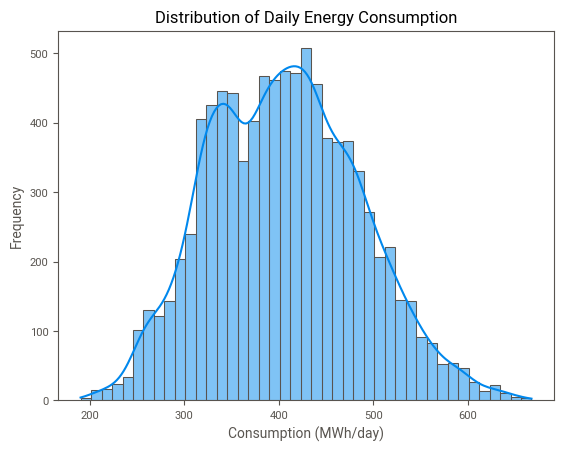

In [50]:
sns.histplot(df1['consumption_mwh_day'], kde=True)
plt.title('Distribution of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.ylabel('Frequency')
plt.show()

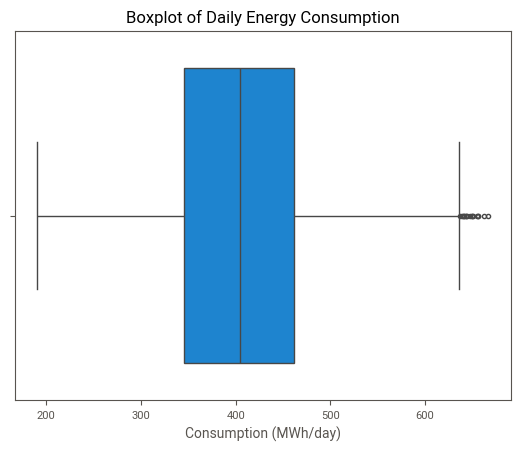

In [51]:
sns.boxplot(x=df1['consumption_mwh_day'])
plt.title('Boxplot of Daily Energy Consumption')
plt.xlabel('Consumption (MWh/day)')
plt.show()

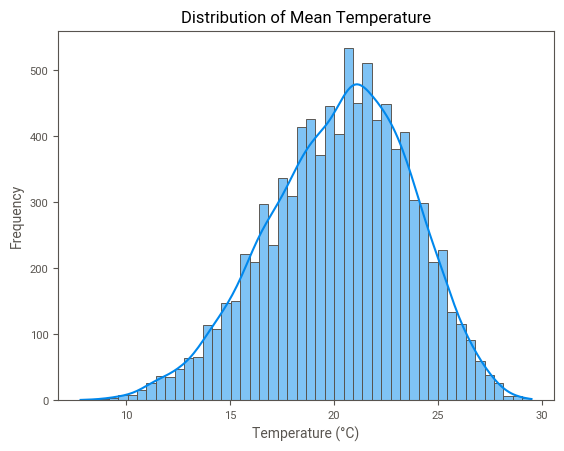

In [52]:
sns.histplot(df1['temp_mean_c'], kde=True)
plt.title('Distribution of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

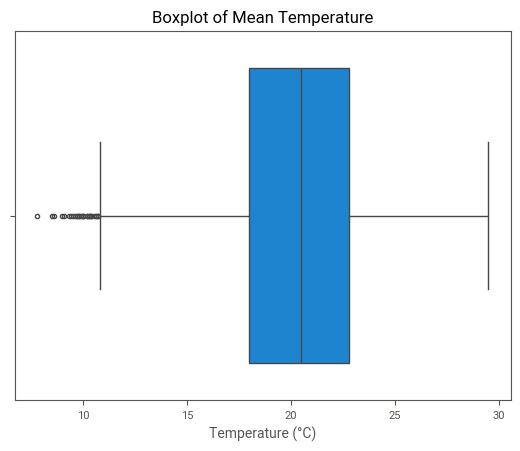

In [53]:
sns.boxplot(x=df1['temp_mean_c'])   
plt.title('Boxplot of Mean Temperature')
plt.xlabel('Temperature (°C)')
plt.show()  